---
date: "2026-04-11"
date-modified: last-modified
format:
  html:
    toc: true
---

# De Montmort's Matching Problem (Derangements)

## 1\. Problem Statement

A well-shuffled deck of $n$ cards is given, labeled $1$ through $n$. You flip the cards over one by one, counting aloud from $1$ to $n$. You win the game if, at any point, the number you say aloud exactly matches the number written on the card being flipped (e.g., if the 49th card in the deck is actually labeled 49).

What is the probability of winning this game?

*(Note: An ordering of the deck where you lose—meaning absolutely no card matches its position—is mathematically known as a **derangement**).*

## 2\. Formal Setup

Let $A_i$ be the [event](event.ipynb) that the $i$-th card in the deck has the number $i$ written on it.

To win the game, we need *at least one* card to match its position. Mathematically, this is the probability of the union of all events $A_i$:
$$P\left(\bigcup_{i=1}^n A_i\right)$$

Because these events overlap (it is possible for both card 2 and card 5 to be in their correct spots simultaneously), we cannot simply add their probabilities. We must use the principle of [inclusion-exclusion](inclusion-exclusion.ipynb).

## 3\. Calculating the Intersections

To apply Inclusion-Exclusion, we need the probabilities of individual events and their intersections. We can calculate these using the [probability-naive-definition](probability-naive-definition.ipynb) since all $n!$ permutations of the deck are equally likely.

  * **Single Events:** To find $P(A_i)$, we fix the card labeled $i$ in the $i$-th position. The remaining $n-1$ cards can be arranged in $(n-1)!$ ways.
    $$P(A_i) = \frac{(n-1)!}{n!} = \frac{1}{n}$$
    *(Alternatively, by symmetry, card $i$ is equally likely to be in any of the $n$ positions, so its chance of being in position $i$ is $1/n$).*

  * **Intersection of Two Events:** To find $P(A_i \cap A_j)$, we fix cards $i$ and $j$ in their respective positions. The remaining $n-2$ cards can be arranged in $(n-2)!$ ways.
    $$P(A_i \cap A_j) = \frac{(n-2)!}{n!} = \frac{1}{n(n-1)}$$

  * **Intersection of $k$ Events:**
    Following the pattern, fixing $k$ specific cards in their correct spots leaves $(n-k)!$ ways to arrange the rest.
    $$P(A_{i_1} \cap \dots \cap A_{i_k}) = \frac{(n-k)!}{n!} = \frac{1}{n(n-1)\dots(n-k+1)}$$

## 4\. Applying Inclusion-Exclusion

The [inclusion-exclusion](inclusion-exclusion.ipynb) formula for $n$ events states:
$$P\left(\bigcup_{i=1}^n A_i\right) = \sum P(A_i) - \sum P(A_i \cap A_j) + \sum P(A_i \cap A_j \cap A_k) - \dots$$

By the symmetry of the problem:

  * There are $\binom{n}{1} = n$ terms of size 1.
  * There are $\binom{n}{2}$ terms of size 2.
  * There are $\binom{n}{k}$ terms of size $k$.

Substituting our probabilities into the formula:
$$P\left(\bigcup_{i=1}^n A_i\right) = n\left(\frac{1}{n}\right) - \binom{n}{2}\left(\frac{1}{n(n-1)}\right) + \binom{n}{3}\left(\frac{1}{n(n-1)(n-2)}\right) - \dots$$

Recall the expansion of the binomial coefficient: $\binom{n}{k} = \frac{n!}{k!(n-k)!}$.
Notice how beautifully the terms cancel out:
$$\binom{n}{k} \frac{(n-k)!}{n!} = \frac{n!}{k!(n-k)!} \frac{(n-k)!}{n!} = \frac{1}{k!}$$

Thus, the entire probability simplifies to a stunning alternating series:
$$P\left(\bigcup_{i=1}^n A_i\right) = 1 - \frac{1}{2!} + \frac{1}{3!} - \frac{1}{4!} + \dots + (-1)^{n+1} \frac{1}{n!}$$

## 5\. The Asymptotic Limit ($n \to \infty$)

What happens if we play this game with a massive deck of cards?
Recall the Taylor series expansion for $e^x$:
$$e^x = 1 + \frac{x}{1!} + \frac{x^2}{2!} + \frac{x^3}{3!} + \dots$$

If we evaluate this at $x = -1$:
$$e^{-1} = 1 - 1 + \frac{1}{2!} - \frac{1}{3!} + \frac{1}{4!} - \dots = 1 - \left(1 - \frac{1}{2!} + \frac{1}{3!} - \frac{1}{4!} + \dots \right)$$

Therefore, our winning probability is exactly the Taylor series for $1 - e^{-1}$ (truncated at $n$ terms). As $n$ grows large:
$$\lim_{n \to \infty} P(\text{Win}) = 1 - \frac{1}{e} \approx 0.63212$$

:::{.callout-note}
### Intuition
As the deck gets larger, the number of *opportunities* to find a match increases, but the probability of *any specific* card matching decreases. These two opposing forces perfectly balance out to a constant probability of about $63.2\%$, regardless of whether you play with 100 cards or 1,000,000 cards\!
:::

## 6\. Python Simulation

You can run this snippet in a Jupyter cell to empirically verify the theorem using a Monte Carlo simulation.

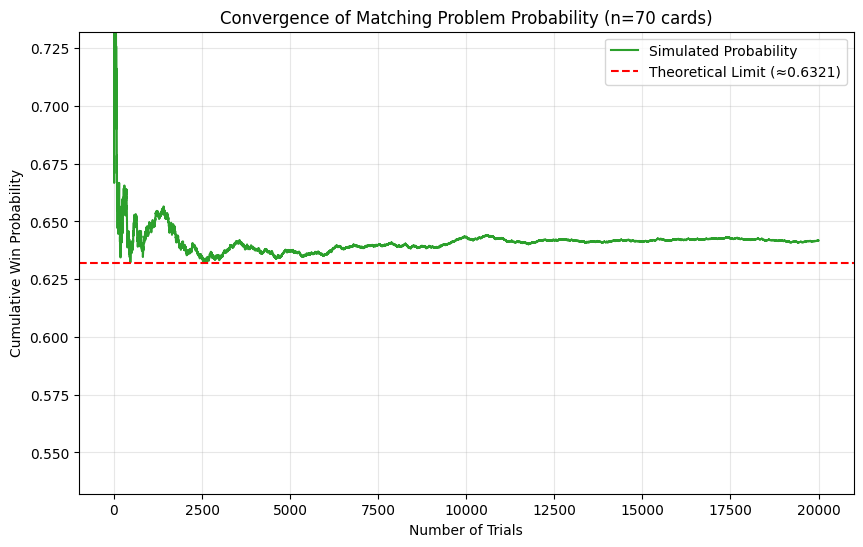

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def run_matching_simulation(n_cards=52, n_trials=5000):
    """
    Simulates de Montmort's game and plots the cumulative win probability.
    """
    target = np.arange(1, n_cards + 1)
    results = []
    
    for _ in range(n_trials):
        # Shuffle the deck
        deck = np.random.permutation(target)
        # A win occurs if at least one card matches its index
        results.append(np.any(deck == target))
    
    # Calculate cumulative probability
    cumulative_wins = np.cumsum(results)
    trial_indices = np.arange(1, n_trials + 1)
    cumulative_prob = cumulative_wins / trial_indices
    
    # Theoretical Limit
    theoretical_limit = 1 - (1 / np.e)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(trial_indices, cumulative_prob, label='Simulated Probability', color='#2ca02c')
    plt.axhline(y=theoretical_limit, color='r', linestyle='--', label=f'Theoretical Limit (≈{theoretical_limit:.4f})')
    
    plt.title(f"Convergence of Matching Problem Probability (n={n_cards} cards)")
    plt.xlabel("Number of Trials")
    plt.ylabel("Cumulative Win Probability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(theoretical_limit - 0.1, theoretical_limit + 0.1)
    plt.show()

# Execute simulation
run_matching_simulation(n_cards=70, n_trials=20000)